In [1]:
!pip install xgboost scikit-learn pandas numpy seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-2.3.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.7-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp314-cp314-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.3/72.0 MB 7.8 MB/s eta 0:00:10



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('Airline_Delay_Cause.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
# Load the dataset
# Run the first cell to get path of the dataset
df = pd.read_csv('Airline_Delay_Cause.csv')

df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,6248.0,2023.000000,0.000000,2023.0,2023.0000,2023.00,2023.000,2023.00
month,6248.0,6.490077,1.128341,4.0,5.0000,6.00,7.000,8.00
arr_flights,6236.0,379.510584,1061.446807,1.0,53.0000,100.00,259.000,20084.00
arr_del15,6236.0,88.597659,244.597184,0.0,9.0000,22.00,64.000,4142.00
carrier_ct,6236.0,29.715035,71.539065,0.0,3.0875,8.66,25.020,1293.91
weather_ct,6236.0,3.462894,10.684250,0.0,0.0000,1.00,2.940,266.42
nas_ct,6235.0,20.963663,66.332268,0.0,1.0000,4.19,12.950,1068.20
security_ct,6235.0,0.268651,1.094751,0.0,0.0000,0.00,0.000,24.46
late_aircraft_ct,6235.0,34.196005,107.098158,0.0,2.0000,6.77,22.255,2069.07
arr_cancelled,6235.0,6.308099,24.801286,0.0,0.0000,1.00,4.000,584.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6248 entries, 0 to 6247
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 6248 non-null   int64  
 1   month                6248 non-null   int64  
 2   carrier              6248 non-null   object 
 3   carrier_name         6248 non-null   object 
 4   airport              6248 non-null   object 
 5   airport_name         6248 non-null   object 
 6   arr_flights          6236 non-null   float64
 7   arr_del15            6236 non-null   float64
 8   carrier_ct           6236 non-null   float64
 9   weather_ct           6236 non-null   float64
 10  nas_ct               6235 non-null   float64
 11  security_ct          6235 non-null   float64
 12  late_aircraft_ct     6235 non-null   float64
 13  arr_cancelled        6235 non-null   float64
 14  arr_diverted         6235 non-null   float64
 15  arr_delay            6235 non-null   f

In [6]:
df.isnull().sum()

,0
year,0
month,0
carrier,0
carrier_name,0
airport,0
airport_name,0
arr_flights,12
arr_del15,12
carrier_ct,12
weather_ct,12


In [7]:
numerical_columns = ['arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())


In [ ]:
df.isnull().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

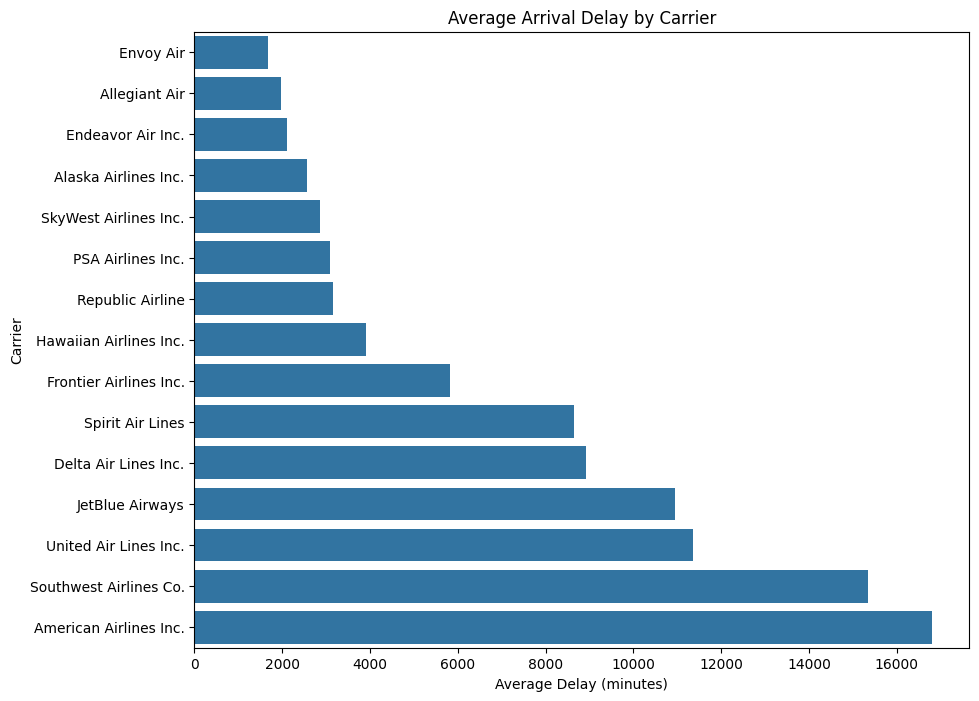

In [8]:
# Performance Analysis Example: Average delay by carrier
carrier_delay_avg = df.groupby('carrier_name')['arr_delay'].mean().sort_values()
plt.figure(figsize=(10, 8))
sns.barplot(x=carrier_delay_avg, y=carrier_delay_avg.index)
plt.title('Average Arrival Delay by Carrier')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Carrier')
plt.show()

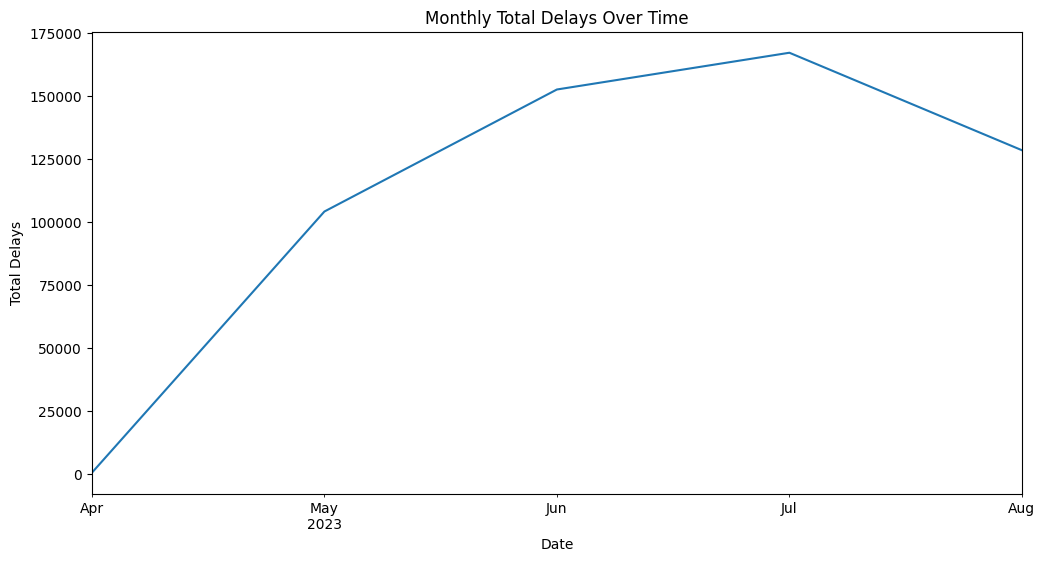

In [9]:
# Trend Identification Example: Total delays over time
df['date'] = pd.to_datetime(df[['year', 'month']].assign(DAY=1))
monthly_delays = df.groupby('date')['arr_del15'].sum()
plt.figure(figsize=(12, 6))
monthly_delays.plot(kind='line')
plt.title('Monthly Total Delays Over Time')
plt.xlabel('Date')
plt.ylabel('Total Delays')
plt.show()

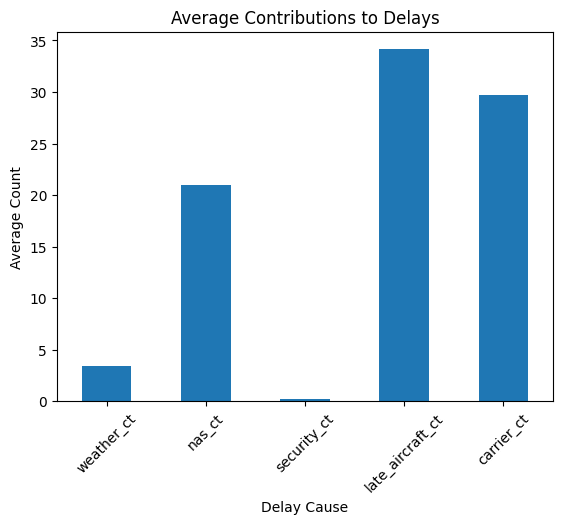

In [10]:
# Root Cause Analysis: Contribution of delay factors
delay_factors = df[['weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'carrier_ct']].mean()
delay_factors.plot(kind='bar')
plt.title('Average Contributions to Delays')
plt.xlabel('Delay Cause')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.show()

In [11]:
# Convert categorical columns to One Hot Encoding
categorical_columns = ['carrier', 'carrier_name', 'airport', 'airport_name']
df = pd.get_dummies(df, columns=categorical_columns, dtype=int)
df.isnull().sum()

,0
year,0
month,0
arr_flights,0
arr_del15,0
carrier_ct,0
...,...
"airport_name_Wilmington, NC: Wilmington International",0
"airport_name_Worcester, MA: Worcester Regional",0
"airport_name_Wrangell, AK: Wrangell Airport",0
"airport_name_Yakutat, AK: Yakutat Airport",0


In [12]:
# Data Preprocessing for Predictive Modeling
# Simplification for demonstration purposes
columns_to_drop = ['year', 'month', 'arr_del15']
df_features = df.drop(columns=columns_to_drop)

X = df_features
datetime_columns = X.select_dtypes(include=['datetime64[ns]']).columns
X = X.drop(columns=datetime_columns)

X = X.astype(float)
y = df['arr_del15'] # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:


X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6248 entries, 0 to 6247
Columns: 732 entries, arr_flights to airport_name_Yuma, AZ: Yuma MCAS/Yuma International
dtypes: float64(732)
memory usage: 34.9 MB


In [14]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print(f"Linear Regression R^2 Score: {r2_score(y_test, y_pred_lr)}")
print(f"Linear Regression MSE: {mean_squared_error(y_test, y_pred_lr)}")

Linear Regression R^2 Score: 0.9999998633734322
Linear Regression MSE: 0.005320972952001324


In [15]:
# XGBRegressor Model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBRegressor R^2 Score: {r2_score(y_test, y_pred_xgb)}")
print(f"XGBRegressor MSE: {mean_squared_error(y_test, y_pred_xgb)}")

XGBRegressor R^2 Score: 0.9915552648728546
XGBRegressor MSE: 328.88337831017014


In [18]:
X.iloc[0:1]

,arr_flights,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,...,"airport_name_West Yellowstone, MT: Yellowstone","airport_name_White Plains, NY: Westchester County","airport_name_Wichita Falls, TX: Sheppard AFB/Wichita Falls Municipal","airport_name_Wichita, KS: Wichita Dwight D Eisenhower National","airport_name_Williston, ND: Williston Basin International","airport_name_Wilmington, NC: Wilmington International","airport_name_Worcester, MA: Worcester Regional","airport_name_Wrangell, AK: Wrangell Airport","airport_name_Yakutat, AK: Yakutat Airport","airport_name_Yuma, AZ: Yuma MCAS/Yuma International"
0,89.0,2.25,1.6,3.16,0.0,5.99,2.0,1.0,1375.0,71.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
sample = X.iloc[0:1]   # taking first row as example
future_prediction = xgb_model.predict(sample)
print("\nPredicted delay for sample row:", future_prediction[0])


Predicted delay for sample row: 11.7338505


In [17]:
sample = X.iloc[0:1]   # taking first row as example
future_prediction = lr_model.predict(sample)
print("\nPredicted delay for sample row:", future_prediction[0])


Predicted delay for sample row: 12.973117536160558


Descriptive

(171666, 21)
year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object
year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            24

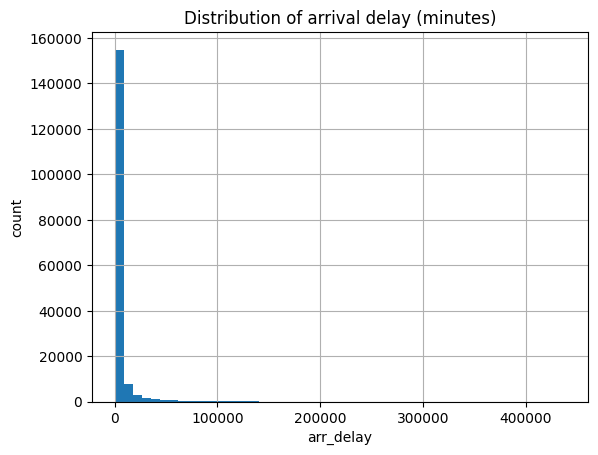

       carrier airport  arr_flights  arr_del15  p_del15
69674       YX     GEG          1.0        1.0      1.0
171664      DL     SBN          1.0        1.0      1.0
65615       OO     CSG          1.0        1.0      1.0
70247       EV     AZO          2.0        2.0      1.0
70248       EV     BDL          1.0        1.0      1.0
133929      EV     MCO          1.0        1.0      1.0
134208      OO     MIA          1.0        1.0      1.0
31740       HA     PPG          2.0        2.0      1.0
134420      DL     FAI          1.0        1.0      1.0
134486      DL     TVC          1.0        1.0      1.0


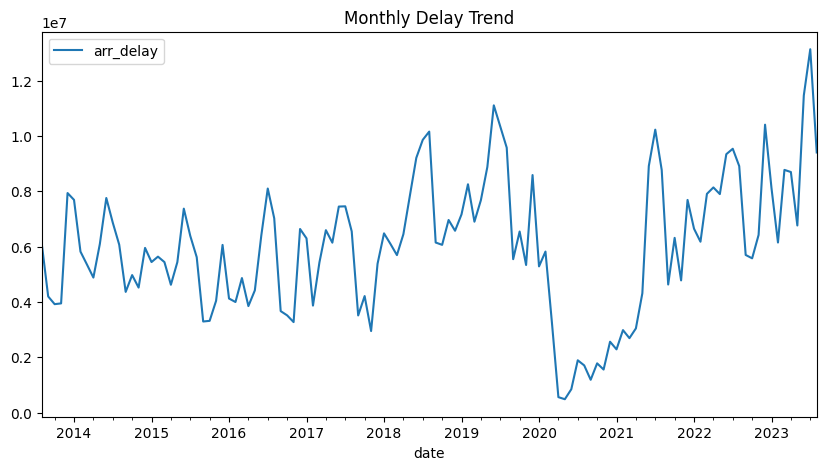

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Airline_Delay_Cause.csv")

# Quick overview
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

# Summary stats for your numeric columns
numerical_columns = [
 'arr_flights','arr_del15','carrier_ct','weather_ct','nas_ct','security_ct',
 'late_aircraft_ct','arr_cancelled','arr_diverted','arr_delay','carrier_delay',
 'weather_delay','nas_delay','security_delay','late_aircraft_delay'
]
print(df[numerical_columns].describe().T)

# Basic aggregations
by_carrier = df.groupby(['carrier','carrier_name'])[numerical_columns].sum().sort_values('arr_delay', ascending=False)
print(by_carrier[['arr_flights','arr_del15','arr_delay']].head(10))

# Distribution plots
df['arr_delay'].hist(bins=50)
plt.title("Distribution of arrival delay (minutes)")
plt.xlabel("arr_delay"); plt.ylabel("count"); plt.show()

# Proportion of flights with >15 min delay
df['p_del15'] = df['arr_del15'] / df['arr_flights']
print(df[['carrier','airport','arr_flights','arr_del15','p_del15']].sort_values('p_del15', ascending=False).head(10))

# Time-based aggregation (if you have day info)
time_agg = df.groupby(['year','month']).agg({
    'arr_delay': 'sum',
    'arr_flights': 'sum',
    'arr_del15': 'sum'
}).reset_index()

time_agg['date'] = pd.to_datetime(time_agg[['year','month']].assign(day=1))

time_agg.plot(x='date', y='arr_delay', figsize=(10,5), title='Monthly Delay Trend')
plt.show()




Diagnostic

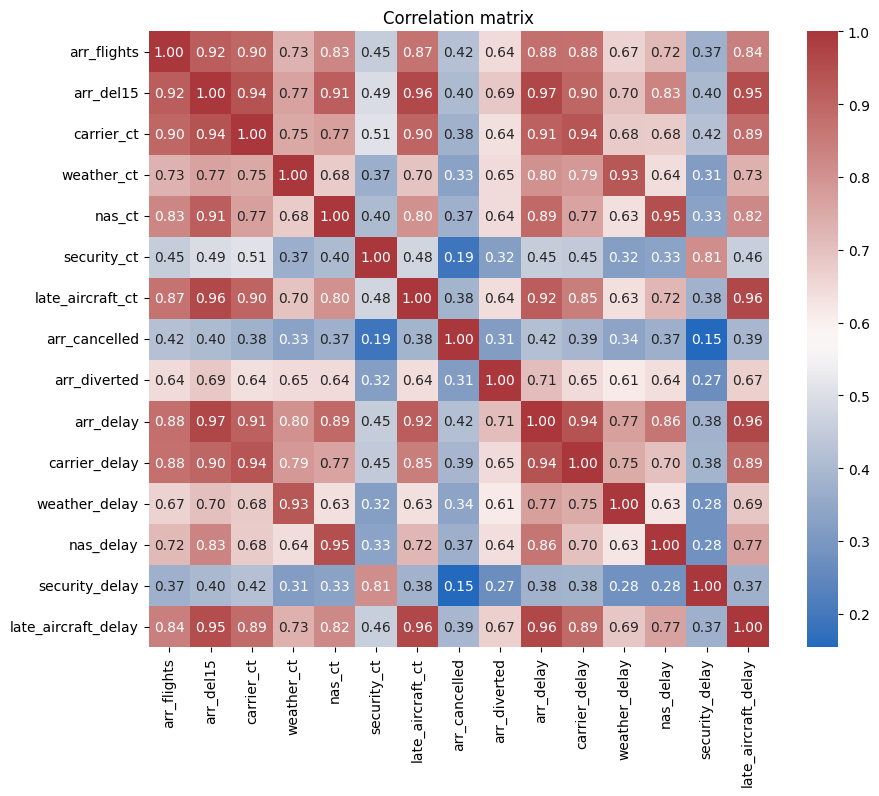

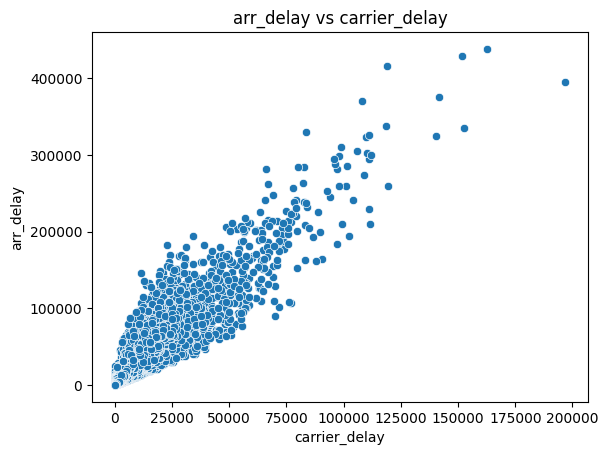

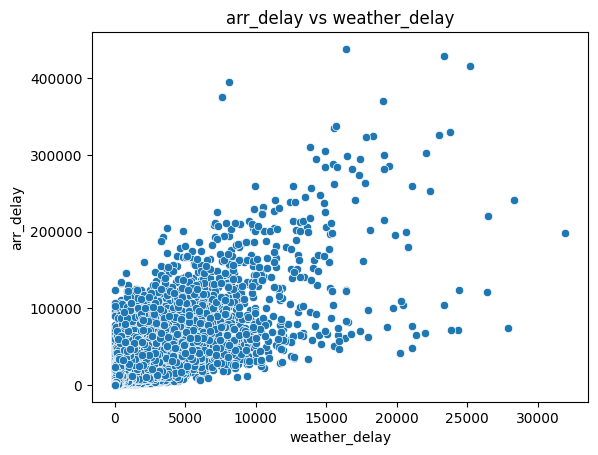

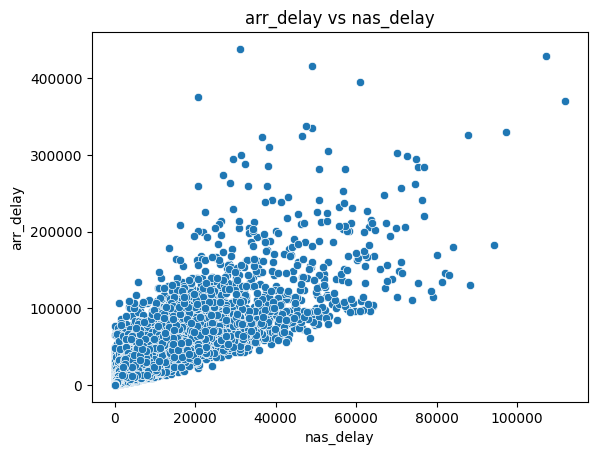

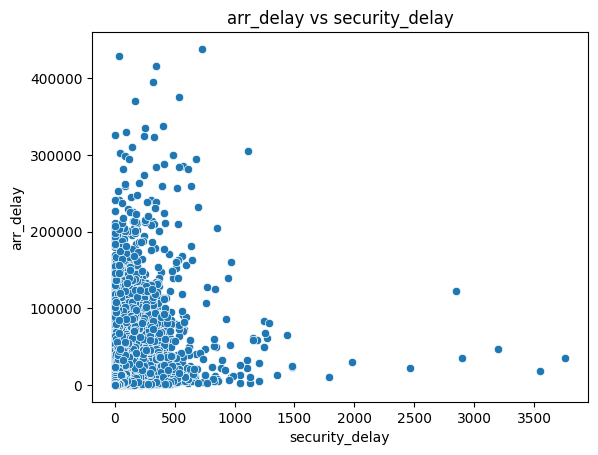

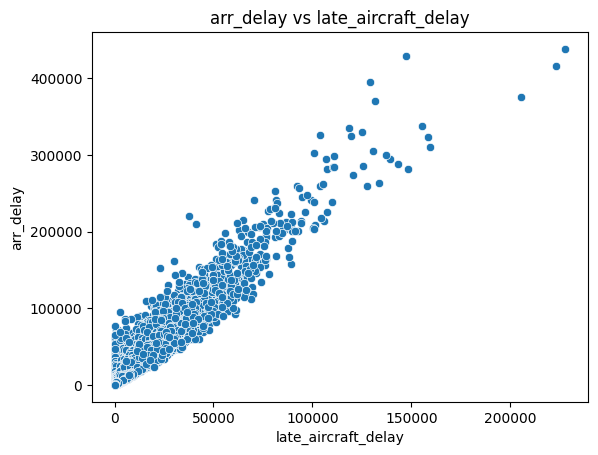

Proportion of recorded delay minutes by cause:
 carrier_delay          0.339000
weather_delay          0.052498
nas_delay              0.217161
security_delay         0.001741
late_aircraft_delay    0.389599
dtype: float64


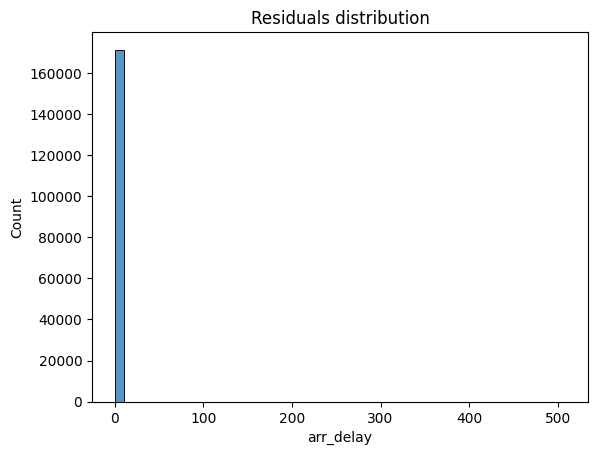

In [3]:
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor

features = [
    'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
    'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
    'late_aircraft_delay'
]


df = df.dropna(subset=['arr_delay'])
y = df['arr_delay']
X = df[features].fillna(df[features].median())


# 1. Correlation matrix
corr = df[numerical_columns].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag")
plt.title("Correlation matrix")
plt.show()

# 2. Pairwise checks: arr_delay vs each cause
for col in ['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']:
    sns.scatterplot(x=df[col], y=df['arr_delay'])
    plt.title(f"arr_delay vs {col}")
    plt.xlabel(col); plt.ylabel('arr_delay')
    plt.show()

# 3. Quantify: percent contribution of causes (simple approach)
total_delay = df['arr_delay'].sum()
contrib = df[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].sum() / total_delay
print("Proportion of recorded delay minutes by cause:\n", contrib)


# 5. Residual analysis from a simple linear model
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X, y)
residuals = y - lr.predict(X)
sns.histplot(residuals, bins=50)
plt.title("Residuals distribution"); plt.show()



PREDICTIVE

LR R2: 0.999999955121205 MSE: 7.556488992687407 MAE: 0.01686585030218375
XGB R2: 0.9664898748878512 MSE: 5642283.652980571 MAE: 201.1750596698076
XGB CV RMSE: 1955.3453435544448


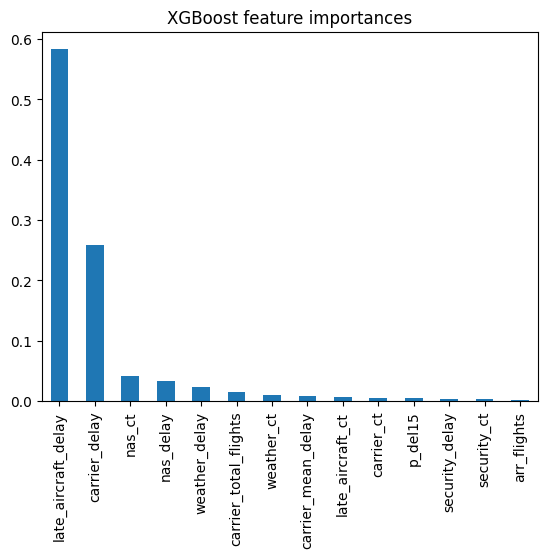

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# Feature engineering suggestions:
# - p_del15 = arr_del15 / arr_flights
# - delay_rate_by_carrier = total_arr_delay_by_carrier / total_flights_by_carrier (merge groupby back)
df['p_del15'] = df['arr_del15'] / df['arr_flights']
# Example: carrier-level aggregated features
carrier_agg = df.groupby('carrier').agg({'arr_delay':'mean','arr_flights':'sum'}).rename(columns={'arr_delay':'carrier_mean_delay','arr_flights':'carrier_total_flights'})
df = df.merge(carrier_agg, on='carrier', how='left')

# Define X, y
features = ['arr_flights','p_del15','carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct',
            'carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay',
            'carrier_mean_delay','carrier_total_flights']
X = df[features].fillna(df[features].median())
y = df['arr_delay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline: Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("LR R2:", r2_score(y_test,y_pred_lr), "MSE:", mean_squared_error(y_test,y_pred_lr), "MAE:", mean_absolute_error(y_test,y_pred_lr))

# Stronger: XGBoost
xgb = XGBRegressor(n_estimators=200, random_state=42, tree_method='hist')
xgb.fit(X_train, y_train, eval_set=[(X_test,y_test)], verbose=False)
y_pred_xgb = xgb.predict(X_test)
print("XGB R2:", r2_score(y_test,y_pred_xgb), "MSE:", mean_squared_error(y_test,y_pred_xgb), "MAE:", mean_absolute_error(y_test,y_pred_xgb))

# Cross-validated RMSE
cv_scores = -cross_val_score(xgb, X, y, cv=5, scoring='neg_root_mean_squared_error')
print("XGB CV RMSE:", cv_scores.mean())

# Feature importance
pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).plot(kind='bar')
plt.title("XGBoost feature importances"); plt.show()


PRESCRIPTIVE

In [7]:
import pandas as pd
import numpy as np

# Example XGBoost model already trained earlier (xgb_model)
# Example predictions for test data:
df['predicted_delay'] = xgb.predict(X)

def prescriptive_actions(row):
    actions = []

    # Rule 1: If predicted delay is VERY high
    if row['predicted_delay'] > 60:
        actions.append("Trigger passenger delay alert")
        actions.append("Assign additional ground staff")
        actions.append("Notify operations control center")

    # Rule 2: High weather impact
    if row['weather_delay'] > row['arr_delay'] * 0.4:
        actions.append("Activate weather contingency plan")
        actions.append("Pre-position support crew")

    # Rule 3: Late aircraft cause dominating
    if row['late_aircraft_delay'] == max([
        row['carrier_delay'], row['weather_delay'], row['nas_delay'],
        row['security_delay'], row['late_aircraft_delay']
    ]):
        actions.append("Increase turnaround buffer time for aircraft")
        actions.append("Optimize aircraft rotation scheduling")

    # Rule 4: Chronic airport issue
    if row['arr_del15'] / row['arr_flights'] > 0.25:
        actions.append("Investigate airport congestion pattern")
        actions.append("Negotiate better slot times")

    # Rule 5: Carrier causing major delays
    if row['carrier_delay'] > row['arr_delay'] * 0.5:
        actions.append("Escalate root-cause analysis to carrier operations team")

    if not actions:
        actions.append("No major action required")

    return actions

df['Prescriptive_Action'] = df.apply(prescriptive_actions, axis=1)

# View results
df[['airport','carrier','predicted_delay','Prescriptive_Action']].head(10)


,airport,carrier,predicted_delay,Prescriptive_Action
0,ABE,9E,1310.252686,"[Trigger passenger delay alert, Assign additio..."
1,ABY,9E,733.722351,"[Trigger passenger delay alert, Assign additio..."
2,AEX,9E,787.655090,"[Trigger passenger delay alert, Assign additio..."
3,AGS,9E,1324.634644,"[Trigger passenger delay alert, Assign additio..."
4,ALB,9E,1403.052368,"[Trigger passenger delay alert, Assign additio..."
5,ATL,9E,30236.404297,"[Trigger passenger delay alert, Assign additio..."
6,AUS,9E,924.256531,"[Trigger passenger delay alert, Assign additio..."
7,AVL,9E,314.423950,"[Trigger passenger delay alert, Assign additio..."
8,AZO,9E,616.359009,"[Trigger passenger delay alert, Assign additio..."
9,BDL,9E,1466.337769,"[Trigger passenger delay alert, Assign additio..."


DECISIVE

In [8]:
def decisive_decision(row):
    delay = row['predicted_delay']

    # Decision logic
    if delay < 15:
        return "Proceed normally - On-time"

    elif 15 <= delay < 30:
        return "Minor delay expected - Keep schedule, monitor closely"

    elif 30 <= delay < 60:
        return "Moderate delay - Add ground/crew support to reduce impact"

    elif 60 <= delay < 120:
        return "Major delay - Reassign aircraft or adjust gate allocation"

    elif 120 <= delay < 180:
        return "Severe delay - Consider flight rescheduling"

    elif delay >= 180:
        return "Critical delay - Consider cancellation or rerouting"

    else:
        return "No decision"

df['Decisive_Action'] = df.apply(decisive_decision, axis=1)
df[['airport','carrier','predicted_delay','Decisive_Action']].head(10)


,airport,carrier,predicted_delay,Decisive_Action
0,ABE,9E,1310.252686,Critical delay - Consider cancellation or rero...
1,ABY,9E,733.722351,Critical delay - Consider cancellation or rero...
2,AEX,9E,787.655090,Critical delay - Consider cancellation or rero...
3,AGS,9E,1324.634644,Critical delay - Consider cancellation or rero...
4,ALB,9E,1403.052368,Critical delay - Consider cancellation or rero...
5,ATL,9E,30236.404297,Critical delay - Consider cancellation or rero...
6,AUS,9E,924.256531,Critical delay - Consider cancellation or rero...
7,AVL,9E,314.423950,Critical delay - Consider cancellation or rero...
8,AZO,9E,616.359009,Critical delay - Consider cancellation or rero...
9,BDL,9E,1466.337769,Critical delay - Consider cancellation or rero...
